# Experiment 04: Active Neurons & Activations Compression Benchmark

**Experiment Context**: `01_layer_based_bench`  
**Target Model**: `google/gemma-3-1b-it` (Layer 0 `model.layers[0]`, Submodule: `mlp.gate_proj` & `mlp.act_fn`)  
**Evaluation Task**: GLUE MNLI Validation Set (`validation_matched`)  
**Previous Baseline Reference**: Inactive neuron slice (4,500 neurons) achieved **7.42x (86.5%) parameter reduction** with Tucker decomposition while preserving task accuracy (+1.98%).

---

## 🎯 Objective & Scientific Hypothesis

In Experiments 01–03, we established that the **inactive/low-variance slice** of `gate_proj` contains massive spectral redundancy, tolerating up to 60% magnitude sparsity and aggressive 4D Tucker decomposition without degrading downstream reasoning.

In this experiment, we explore the compressibility of the **active neurons** (the top ~2,400 neurons exhibiting high activation variance and non-zero response rates):
1. **Hypothesis**: Active neurons form the primary semantic backbone of the layer. Their singular value spectrum will decay significantly slower (higher intrinsic dimensionality / flatter spectral tail) compared to inactive weights.
2. **Compressibility Frontier**: Because active weights carry task-critical dynamic range, naive aggressive Tucker or heavy truncation will induce severe degradation. We will characterize the exact accuracy-vs-rank pareto frontier.
3. **Factorization Strategies**:
   - **Strategy 1**: High-fidelity Low-Rank SVD (preserving 95%–99% spectral energy).
   - **Strategy 2**: Higher-Order Tensorization & Tucker Decomposition on the reshaped active tensor `[40, 60, 24, 48]`.
   - **Strategy 3**: Comparative sensitivity analysis (Active slice compression vs Inactive slice compression).

In [1]:
# =====================================================================
# STEP 1: Environment Setup, Time Logging & Library Imports
# =====================================================================
import os
import sys
import time
from pathlib import Path
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from datasets import load_dataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from IPython import get_ipython

# Set TensorLy PyTorch backend
tl.set_backend("pytorch")

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

# =====================================================================
# TIME LOGGING SYSTEM: Per-Cell & Global Notebook Timers
# =====================================================================
GLOBAL_NOTEBOOK_START_TIME = time.time()
NOTEBOOK_TIMINGS = []
_current_cell_start = None

ip = get_ipython()
if ip is not None:
    def _pre_cell_hook(info):
        global _current_cell_start
        _current_cell_start = time.time()

    def _post_cell_hook(result):
        global _current_cell_start
        if _current_cell_start is not None:
            elapsed = time.time() - _current_cell_start
            cumulative = time.time() - GLOBAL_NOTEBOOK_START_TIME
            cell_id = result.execution_count or len(NOTEBOOK_TIMINGS) + 1

            timing_entry = {
                "cell_id": cell_id,
                "time": round(elapsed, 3),
                "cummulative_time": round(cumulative, 3),
            }
            NOTEBOOK_TIMINGS.append(timing_entry)

            print(f"time: {elapsed:.2f}s")
            print(f"cummulative_time: {cumulative:.2f}s")

    ip.events.register("pre_run_cell", _pre_cell_hook)
    ip.events.register("post_run_cell", _post_cell_hook)

# Neural Decomp framework imports (with fallback support)
try:
    from neural_decomp import ModelManagementInterface, DeviceMapOptions, ActivationHookManager
    from neural_decomp.decomposition import (
        decompose_svd,
        compute_spectral_energy,
        truncate_svd,
        decompose_tucker,
    )
    from neural_decomp.profiling import (
        summarize_activations,
        partition_inactive_neurons,
        compute_dead_neuron_ratio,
        compute_outlier_ratio,
    )
    from neural_decomp.evaluation import evaluate_mnli
    from neural_decomp.utils import get_device_info, save_json_metrics, print_section
    print("Loaded neural_decomp library.")
except ImportError:
    from utility import ModelManagementInterface, DeviceMapOptions, ActivationHookManager
    from utility.decomposition import (
        decompose_svd,
        compute_spectral_energy,
        truncate_svd,
        decompose_tucker,
    )
    from utility.profiling import (
        summarize_activations,
        partition_inactive_neurons,
        compute_dead_neuron_ratio,
        compute_outlier_ratio,
    )
    from utility.evaluation import evaluate_mnli
    from utility.utils import get_device_info, save_json_metrics, print_section
    print("Loaded utility library.")

# Inspect hardware environment
device_info = get_device_info()
# Set TensorLy PyTorch backend
print(f"Device: {device_info['device_name']} | CUDA Available: {device_info['cuda_available']}")
if device_info["cuda_available"]:
    print(f"Allocated VRAM: {device_info.get('allocated_gb', 0.0)} GB")

/home/dwithun/Development/llm_compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded neural_decomp library.
Device: NVIDIA GeForce RTX 3070 Ti | CUDA Available: True
Allocated VRAM: 0.0 GB


In [2]:
# =====================================================================
# STEP 2: Initialize Model & Tokenizer
# =====================================================================
model_id = "google/gemma-3-1b-it"

mmi = ModelManagementInterface(
    model_id=model_id,
    precision=torch.float32,
    device_map=DeviceMapOptions.BALANCED,
)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

# Target Submodule: Layer 0 MLP gate projection
target_layer = model.model.layers[0]
target_submodule = target_layer.mlp.gate_proj

print(f"Model ID: {model_id}")
print(f"Target Layer: Layer 0 ({target_layer.__class__.__name__})")
print(f"Target Submodule: gate_proj ({target_submodule.weight.shape[0]} x {target_submodule.weight.shape[1]})")
print(f"Total Submodule Parameters: {target_submodule.weight.numel():,}")

# Keep an immutable reference copy of pristine original weights for clean rollbacks
W_gate_orig = target_submodule.weight.data.clone()

Loading weights: 100%|██████████| 340/340 [00:01<00:00, 300.23it/s]


Model ID: google/gemma-3-1b-it
Target Layer: Layer 0 (Gemma3DecoderLayer)
Target Submodule: gate_proj (6912 x 1152)
Total Submodule Parameters: 7,962,624
time: 4.52s
cummulative_time: 6.93s


In [3]:
# =====================================================================
# STEP 3: Load GLUE MNLI Validation Benchmark
# =====================================================================
ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]

label_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0] for name in label_names]

# Configure evaluation sample size for interactive experiments
EVAL_SAMPLE_COUNT = 7000
eval_data = ds.select(range(EVAL_SAMPLE_COUNT))

print(f"Loaded GLUE MNLI validation split: {len(ds):,} total samples")
print(f"Active Evaluation Subset: {len(eval_data):,} samples")
print(f"Candidate Label IDs: {dict(zip(label_names, label_token_ids))}")

Loaded GLUE MNLI validation split: 9,815 total samples
Active Evaluation Subset: 7,000 samples
Candidate Label IDs: {'entailment': 83155, 'neutral': 12643, 'contradiction': 38912}
time: 3.56s
cummulative_time: 10.49s


---
## 🔍 Baseline Evaluation & Activation Profiling

Before altering any weights, we record the pristine uncompressed baseline accuracy on the evaluation subset and capture the sample activations of Layer 0 submodules using `ActivationHookManager`.

In [4]:
# =====================================================================
# STEP 4: Capture Layer 0 Activations & Establish Baseline Accuracy
# =====================================================================
hook_mgr = ActivationHookManager(target_layer)

benchmark_activations = {
    name: [] for name, _ in target_layer.named_modules() if name != ""
}
current_step_acts = {}

def capture_hook(submodule_name):
    def hook(module, input, output):
        act = output[0] if isinstance(output, tuple) else output
        current_step_acts[submodule_name] = act.detach().cpu()
    return hook

handles = []
for name, submodule in target_layer.named_modules():
    if name != "":
        h = submodule.register_forward_hook(capture_hook(name))
        handles.append(h)

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Baseline Inference & Hook Profiling"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        # Collect activations for each submodule
        for name, act_tensor in current_step_acts.items():
            sample_summary = act_tensor.squeeze(0).mean(dim=0)
            benchmark_activations[name].append(sample_summary)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]
        pred_label = torch.argmax(candidate_logits).item()

        predictions.append(pred_label)
        ground_truth.append(sample["label"])

# Remove hook handles
for h in handles:
    h.remove()

baseline_accuracy = accuracy_score(ground_truth, predictions)
print(f"\nUncompressed Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=label_names, zero_division=0))

Baseline Inference & Hook Profiling:  11%|█▏        | 803/7000 [00:31<04:06, 25.15it/s]


KeyboardInterrupt: 

time: 32.38s
cummulative_time: 42.88s


In [ ]:
# =====================================================================
# STEP 5: Pool & Format Activation Profiles
# =====================================================================
for name in benchmark_activations:
    pooled_samples = []
    for item in benchmark_activations[name]:
        arr = item.cpu().numpy() if isinstance(item, torch.Tensor) else np.array(item)
        if arr.ndim == 2:
            pooled = arr.mean(axis=0)
        elif arr.ndim == 3:
            pooled = arr.mean(axis=1).reshape(-1)
        else:
            pooled = arr
        pooled_samples.append(pooled)
    benchmark_activations[name] = np.stack(pooled_samples)

act_fn_acts = benchmark_activations["mlp.act_fn"]  # Shape: [num_samples, 6912]
print(f"Extracted 'mlp.act_fn' activation matrix shape: {act_fn_acts.shape}")

# Summarize distribution metrics
act_summary = summarize_activations(act_fn_acts)
print(f"MLP act_fn Mean:         {act_summary['mean']:.4f}")
print(f"MLP act_fn Std Dev:      {act_summary['std']:.4f}")
print(f"MLP act_fn Dead (<0.05): {act_summary['dead_ratio_pct']:.2f}%")
print(f"MLP act_fn Outliers (>3): {act_summary['outlier_ratio_pct']:.2f}%")

Extracted 'mlp.act_fn' activation matrix shape: (7000, 6912)
MLP act_fn Mean:         0.0802
MLP act_fn Std Dev:      0.3907
MLP act_fn Dead (<0.05): 48.33%
MLP act_fn Outliers (>3): 0.04%
time: 1.61s
cummulative_time: 275.78s


---
## ⚡ Active Neuron Identification & Weight Slicing

We rank all 6,912 neurons in `mlp.act_fn` by their empirical activation variance across prompts:
- **Active Neurons ($K = 2,400$)**: Neurons with the highest variance, carrying high dynamic range and responsiveness.
- **Inactive Neurons ($6,912 - 2,400 = 4,512$)**: Neurons with low or static variance.
- **Weight Slicing**:
  - `W_active = target_submodule.weight.data[active_indices, :]` ($[2400, 1152]$)
  - `W_inactive = target_submodule.weight.data[inactive_indices, :]` ($[4512, 1152]$)

Total Neurons:     6,912
Active Neurons:    2,400 (34.7%)
Inactive Neurons:  4,512 (65.3%)
Active Variance Range:   [0.00127, 0.07708]
Inactive Variance Range: [0.00001, 0.00127]

W_active shape:   [2400, 1152] (2,764,800 parameters)
W_inactive shape: [4512, 1152] (5,197,824 parameters)


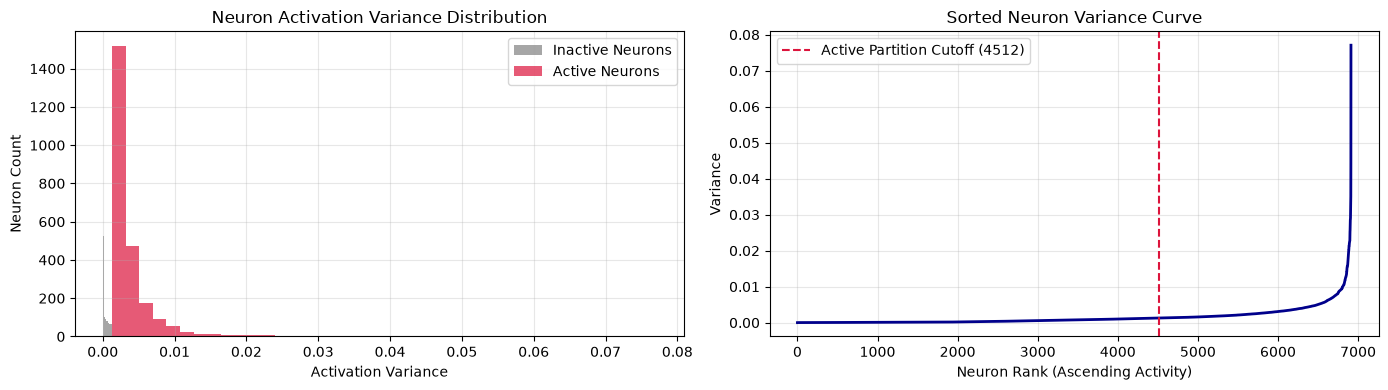

time: 0.41s
cummulative_time: 276.20s


In [ ]:
# =====================================================================
# STEP 6: Partition Neurons into Active vs Inactive Subsets
# =====================================================================
NUM_ACTIVE = 2400  # Highly factorable: 2400 = 40 * 60 or 24 * 100
total_neurons = act_fn_acts.shape[1]
num_inactive = total_neurons - NUM_ACTIVE

neuron_variances = np.var(act_fn_acts, axis=0)
sorted_neuron_indices = np.argsort(neuron_variances)

# Inactive are lowest variance; Active are highest variance
inactive_indices = sorted_neuron_indices[:num_inactive]
active_indices = sorted_neuron_indices[num_inactive:]

print(f"Total Neurons:     {total_neurons:,}")
print(f"Active Neurons:    {len(active_indices):,} ({len(active_indices)/total_neurons*100:.1f}%)")
print(f"Inactive Neurons:  {len(inactive_indices):,} ({len(inactive_indices)/total_neurons*100:.1f}%)")
print(f"Active Variance Range:   [{neuron_variances[active_indices].min():.5f}, {neuron_variances[active_indices].max():.5f}]")
print(f"Inactive Variance Range: [{neuron_variances[inactive_indices].min():.5f}, {neuron_variances[inactive_indices].max():.5f}]")

# Extract the weight slices
W_active = W_gate_orig[active_indices, :].float().cpu()
W_inactive = W_gate_orig[inactive_indices, :].float().cpu()

print(f"\nW_active shape:   {list(W_active.shape)} ({W_active.numel():,} parameters)")
print(f"W_inactive shape: {list(W_inactive.shape)} ({W_inactive.numel():,} parameters)")

# Plot Activation Variance Distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(neuron_variances[inactive_indices], bins=40, color='gray', alpha=0.7, label='Inactive Neurons')
ax[0].hist(neuron_variances[active_indices], bins=40, color='crimson', alpha=0.7, label='Active Neurons')
ax[0].set_title("Neuron Activation Variance Distribution")
ax[0].set_xlabel("Activation Variance")
ax[0].set_ylabel("Neuron Count")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

sorted_vars = np.sort(neuron_variances)
ax[1].plot(sorted_vars, color='darkblue', linewidth=2)
ax[1].axvline(num_inactive, color='crimson', linestyle='--', label=f'Active Partition Cutoff ({num_inactive})')
ax[1].set_title("Sorted Neuron Variance Curve")
ax[1].set_xlabel("Neuron Rank (Ascending Activity)")
ax[1].set_ylabel("Variance")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📊 Comparative Spectral Analysis: Active vs. Inactive Weights

Does the active slice have fundamentally higher intrinsic rank and linear complexity than the inactive slice?
We run Singular Value Decomposition ($W = U \Sigma V^T$) on both slices and contrast their cumulative energy decay curves.

Spectral Energy Retention Comparison (Active vs Inactive):
Threshold | Active Rank Needed (out of 1152) | Inactive Rank Needed
  80%     | 539  (46.8%)               | 648  (56.2%)
  90%     | 719  (62.4%)               | 835  (72.5%)
  95%     | 858  (74.5%)               | 961  (83.4%)
  99%     | 1050 (91.1%)               | 1101 (95.6%)


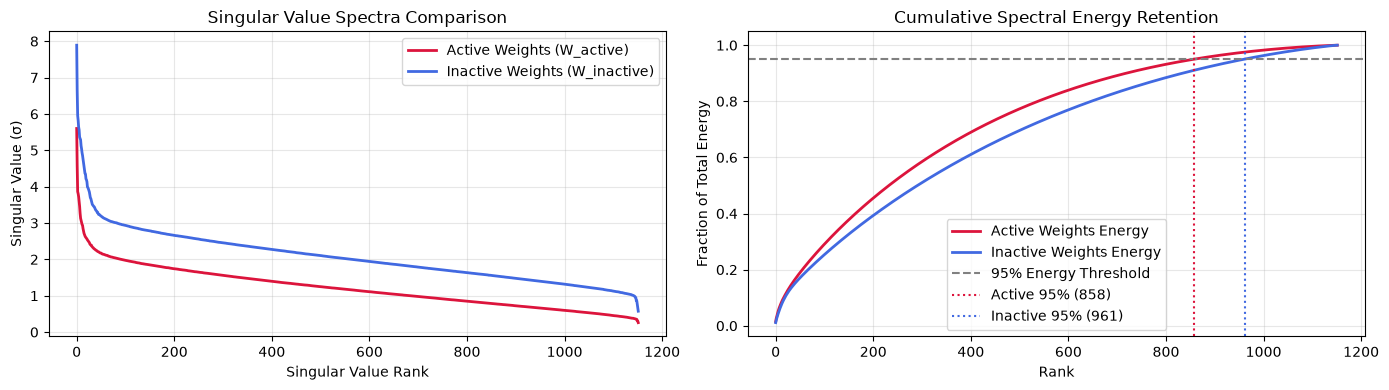

time: 0.70s
cummulative_time: 276.91s


In [ ]:
# =====================================================================
# STEP 7: Compute SVD & Contrast Spectral Decay Curves
# =====================================================================
U_act, S_act, Vh_act = decompose_svd(W_active)
U_inact, S_inact, Vh_inact = decompose_svd(W_inactive)

energy_act = compute_spectral_energy(S_act)
energy_inact = compute_spectral_energy(S_inact)

total_dims = len(S_act)  # min(2400, 1152) = 1152

print("Spectral Energy Retention Comparison (Active vs Inactive):")
print(f"Threshold | Active Rank Needed (out of {total_dims}) | Inactive Rank Needed")
print(f"  80%     | {energy_act['rank_80']:<4} ({energy_act['rank_80']/total_dims*100:.1f}%)               | {energy_inact['rank_80']:<4} ({energy_inact['rank_80']/total_dims*100:.1f}%)")
print(f"  90%     | {energy_act['rank_90']:<4} ({energy_act['rank_90']/total_dims*100:.1f}%)               | {energy_inact['rank_90']:<4} ({energy_inact['rank_90']/total_dims*100:.1f}%)")
print(f"  95%     | {energy_act['rank_95']:<4} ({energy_act['rank_95']/total_dims*100:.1f}%)               | {energy_inact['rank_95']:<4} ({energy_inact['rank_95']/total_dims*100:.1f}%)")
print(f"  99%     | {energy_act['rank_99']:<4} ({energy_act['rank_99']/total_dims*100:.1f}%)               | {energy_inact['rank_99']:<4} ({energy_inact['rank_99']/total_dims*100:.1f}%)")

# Plot singular values and cumulative energy
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(S_act.numpy(), label='Active Weights (W_active)', color='crimson', linewidth=2)
ax[0].plot(S_inact.numpy(), label='Inactive Weights (W_inactive)', color='royalblue', linewidth=2)
ax[0].set_title("Singular Value Spectra Comparison")
ax[0].set_xlabel("Singular Value Rank")
ax[0].set_ylabel("Singular Value (σ)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

cum_energy_act = (torch.cumsum(S_act**2, dim=0) / torch.sum(S_act**2)).numpy()
cum_energy_inact = (torch.cumsum(S_inact**2, dim=0) / torch.sum(S_inact**2)).numpy()

ax[1].plot(cum_energy_act, label='Active Weights Energy', color='crimson', linewidth=2)
ax[1].plot(cum_energy_inact, label='Inactive Weights Energy', color='royalblue', linewidth=2)
ax[1].axhline(0.95, color='gray', linestyle='--', label='95% Energy Threshold')
ax[1].axvline(energy_act['rank_95'], color='crimson', linestyle=':', label=f"Active 95% ({energy_act['rank_95']})")
ax[1].axvline(energy_inact['rank_95'], color='royalblue', linestyle=':', label=f"Inactive 95% ({energy_inact['rank_95']})")
ax[1].set_title("Cumulative Spectral Energy Retention")
ax[1].set_xlabel("Rank")
ax[1].set_ylabel("Fraction of Total Energy")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🧪 Strategy 1: Low-Rank SVD Factorization of Active Weights

We evaluate SVD rank truncation on the active weight slice:
$$\hat{W}_{active} = U_{:, :r} \Sigma_{:r} V_{:r, :}^T$$
We test multiple energy retention ranks (e.g. 99%, 95%, and 90%) to observe when degradation occurs.

In [ ]:
# =====================================================================
# STEP 8: Strategy 1 — Low-Rank SVD Reconstruction & Evaluation
# =====================================================================
svd_test_configs = [
    {"label": "SVD (99% Energy)", "rank": energy_act["rank_99"]},
    {"label": "SVD (95% Energy)", "rank": energy_act["rank_95"]},
    {"label": "SVD (90% Energy)", "rank": energy_act["rank_90"]},
]

svd_results = []

for cfg in svd_test_configs:
    r = cfg["rank"]
    # Reconstruct 2D slice
    W_act_svd = truncate_svd(U_act, S_act, Vh_act, rank=r)
    
    # Relative Frobenius reconstruction error
    rel_error = (torch.norm(W_active - W_act_svd) / torch.norm(W_active)).item()
    
    # Parameter accounting for factorized representation: U_r (M x r) + S_r (r) + V_r (r x N)
    m, n = W_active.shape
    factorized_params = (m * r) + r + (r * n)
    orig_params = m * n
    compression_ratio = orig_params / factorized_params
    eliminated_pct = (1.0 - factorized_params / orig_params) * 100.0
    
    print(f"\nEvaluating {cfg['label']} (Rank {r} / {total_dims})...")
    print(f"  Reconstruction Error: {rel_error * 100:.2f}%")
    print(f"  Factorized Parameters: {factorized_params:,} vs Original {orig_params:,} ({compression_ratio:.2f}x)")
    
    # Inject reconstructed weights into live model
    target_submodule.weight.data = W_gate_orig.clone()
    target_submodule.weight.data[active_indices, :] = W_act_svd.to(
        device=model.device, dtype=target_submodule.weight.dtype
    )
    
    # Evaluate live accuracy on MNLI
    predictions = []
    ground_truth = []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=f"Evaluating {cfg['label']}"):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]
            pred_label = torch.argmax(next_token_logits[label_token_ids]).item()
            predictions.append(pred_label)
            ground_truth.append(sample["label"])
            
    acc = accuracy_score(ground_truth, predictions)
    delta = acc - baseline_accuracy
    print(f"  Final Accuracy: {acc * 100:.2f}% (Δ vs Baseline: {delta * 100:+.2f}%)")
    
    svd_results.append({
        "strategy": cfg["label"],
        "rank": r,
        "parameters": factorized_params,
        "compression_ratio": compression_ratio,
        "eliminated_pct": eliminated_pct,
        "recon_error_pct": rel_error * 100.0,
        "accuracy": acc,
        "delta": delta,
    })

# Restore baseline weights
target_submodule.weight.data = W_gate_orig.clone()
print("\nBaseline weights restored.")


Evaluating SVD (99% Energy) (Rank 1050 / 1152)...
  Reconstruction Error: 9.98%
  Factorized Parameters: 3,730,650 vs Original 2,764,800 (0.74x)


Evaluating SVD (99% Energy): 100%|██████████| 7000/7000 [04:01<00:00, 28.93it/s]


  Final Accuracy: 49.53% (Δ vs Baseline: -0.23%)

Evaluating SVD (95% Energy) (Rank 858 / 1152)...
  Reconstruction Error: 22.35%
  Factorized Parameters: 3,048,474 vs Original 2,764,800 (0.91x)


Evaluating SVD (95% Energy): 100%|██████████| 7000/7000 [04:01<00:00, 28.93it/s]


  Final Accuracy: 49.51% (Δ vs Baseline: -0.24%)

Evaluating SVD (90% Energy) (Rank 719 / 1152)...
  Reconstruction Error: 31.61%
  Factorized Parameters: 2,554,607 vs Original 2,764,800 (1.08x)


Evaluating SVD (90% Energy): 100%|██████████| 7000/7000 [04:02<00:00, 28.92it/s]

  Final Accuracy: 50.30% (Δ vs Baseline: +0.54%)

Baseline weights restored.
time: 726.11s
cummulative_time: 1003.02s


---
## 🧊 Strategy 2: Higher-Order Tensorization & Tucker Decomposition

We fold the 2D active matrix into a 4th-order tensor and test Tucker (HOSVD) decomposition:
$$\text{Matrix } [2400, 1152] \longrightarrow \text{Tensor } [40, 60, 24, 48]$$
Total elements: $40 \times 60 \times 24 \times 48 = 2,764,800$ (exact match).

We explore conservative, high-capacity Tucker ranks:
- **Balanced High-Capacity**: `[32, 48, 18, 36]` (preserving active variance)
- **Moderate Compression**: `[26, 38, 14, 28]`
- **Aggressive Compression**: `[20, 30, 12, 24]` (probing collapse boundary)

In [ ]:
# =====================================================================
# STEP 9: Strategy 2 — 4D Tucker Decomposition on Active Slice
# =====================================================================
tensor_shape = [40, 60, 24, 48]
assert math.prod(tensor_shape) == W_active.numel(), "Tensor dimensions must match weight elements!"

W_active_tensor = W_active.reshape(*tensor_shape).float().cpu()
print(f"Folded active weights into 4D Tensor: {list(W_active_tensor.shape)}")

tucker_configs = [
    {"label": "Tucker (High-Capacity)", "ranks": [32, 48, 18, 36]},
    {"label": "Tucker (Moderate)",      "ranks": [26, 38, 14, 28]},
    {"label": "Tucker (Aggressive)",    "ranks": [20, 30, 12, 24]},
]

tucker_results = []

for cfg in tucker_configs:
    ranks = cfg["ranks"]
    core, factors, W_recon_tensor, metrics = decompose_tucker(W_active_tensor, rank=ranks, init='svd')
    
    # Unfold reconstructed tensor back to [2400, 1152]
    W_act_tucker = W_recon_tensor.reshape(NUM_ACTIVE, 1152)
    
    # Calculate error
    rel_error = (torch.norm(W_active - W_act_tucker) / torch.norm(W_active)).item()
    
    print(f"\nEvaluating {cfg['label']} (Ranks {ranks})...")
    print(f"  Reconstruction Error: {rel_error * 100:.2f}%")
    print(f"  Core Parameters:      {metrics['core_params']:,}")
    print(f"  Factor Parameters:    {metrics['factors_params']:,}")
    print(f"  Total Compressed:     {metrics['total_compressed_params']:,} ({metrics['compression_ratio']:.2f}x)")
    print(f"  Parameters Cut:       {metrics['eliminated_pct']:.2f}%")
    
    # Inject into live model
    target_submodule.weight.data = W_gate_orig.clone()
    target_submodule.weight.data[active_indices, :] = W_act_tucker.to(
        device=model.device, dtype=target_submodule.weight.dtype
    )
    
    # Evaluate live accuracy on MNLI
    predictions = []
    ground_truth = []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=f"Evaluating {cfg['label']}"):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]
            pred_label = torch.argmax(next_token_logits[label_token_ids]).item()
            predictions.append(pred_label)
            ground_truth.append(sample["label"])
            
    acc = accuracy_score(ground_truth, predictions)
    delta = acc - baseline_accuracy
    print(f"  Final Accuracy: {acc * 100:.2f}% (Δ vs Baseline: {delta * 100:+.2f}%)")
    
    tucker_results.append({
        "strategy": cfg["label"],
        "ranks": ranks,
        "parameters": metrics["total_compressed_params"],
        "compression_ratio": metrics["compression_ratio"],
        "eliminated_pct": metrics["eliminated_pct"],
        "recon_error_pct": rel_error * 100.0,
        "accuracy": acc,
        "delta": delta,
    })

# Restore baseline weights
target_submodule.weight.data = W_gate_orig.clone()
print("\nBaseline weights restored.")

Folded active weights into 4D Tensor: [40, 60, 24, 48]

Evaluating Tucker (High-Capacity) (Ranks [32, 48, 18, 36])...
  Reconstruction Error: 76.96%
  Core Parameters:      995,328.0
  Factor Parameters:    6,320.0
  Total Compressed:     1,001,648.0 (2.76x)
  Parameters Cut:       63.77%


Evaluating Tucker (High-Capacity): 100%|██████████| 7000/7000 [04:03<00:00, 28.72it/s]


  Final Accuracy: 49.69% (Δ vs Baseline: -0.07%)

Evaluating Tucker (Moderate) (Ranks [26, 38, 14, 28])...
  Reconstruction Error: 90.60%
  Core Parameters:      387,296.0
  Factor Parameters:    5,000.0
  Total Compressed:     392,296.0 (7.05x)
  Parameters Cut:       85.81%


Evaluating Tucker (Moderate): 100%|██████████| 7000/7000 [04:03<00:00, 28.77it/s]


  Final Accuracy: 38.21% (Δ vs Baseline: -11.54%)

Evaluating Tucker (Aggressive) (Ranks [20, 30, 12, 24])...
  Reconstruction Error: 95.32%
  Core Parameters:      172,800.0
  Factor Parameters:    4,040.0
  Total Compressed:     176,840.0 (15.63x)
  Parameters Cut:       93.60%


Evaluating Tucker (Aggressive): 100%|██████████| 7000/7000 [04:02<00:00, 28.82it/s]

  Final Accuracy: 34.17% (Δ vs Baseline: -15.59%)

Baseline weights restored.
time: 731.74s
cummulative_time: 1734.77s


---
## 📈 Synthesis & Results Export

We aggregate results across all active weight compression strategies and plot the accuracy degradation vs parameter reduction frontier.

Variant                      | Params    | Ratio  | Cut %  | Err %   | Accuracy  | Delta  
Baseline (Uncompressed)      | 2764800   | 1.00x  | 0.0%   | 0.0%    | 49.76%    | +0.00% 
SVD (99% Energy)             | 3730650   | 0.74x  | -34.9% | 9.98%   | 49.53%    | -0.23% 
SVD (95% Energy)             | 3048474   | 0.91x  | -10.3% | 22.35%  | 49.51%    | -0.24% 
SVD (90% Energy)             | 2554607   | 1.08x  | 7.6%   | 31.61%  | 50.30%    | +0.54% 
Tucker (High-Capacity)       | 1001648   | 2.76x  | 63.8%  | 76.96%  | 49.69%    | -0.07% 
Tucker (Moderate)            | 392296    | 7.05x  | 85.8%  | 90.60%  | 38.21%    | -11.54%
Tucker (Aggressive)          | 176840    | 15.63x | 93.6%  | 95.32%  | 34.17%    | -15.59%
cummulative_time: 1734.78s

Benchmark results & timing data saved to: artifacts/04_active_acts_results.json


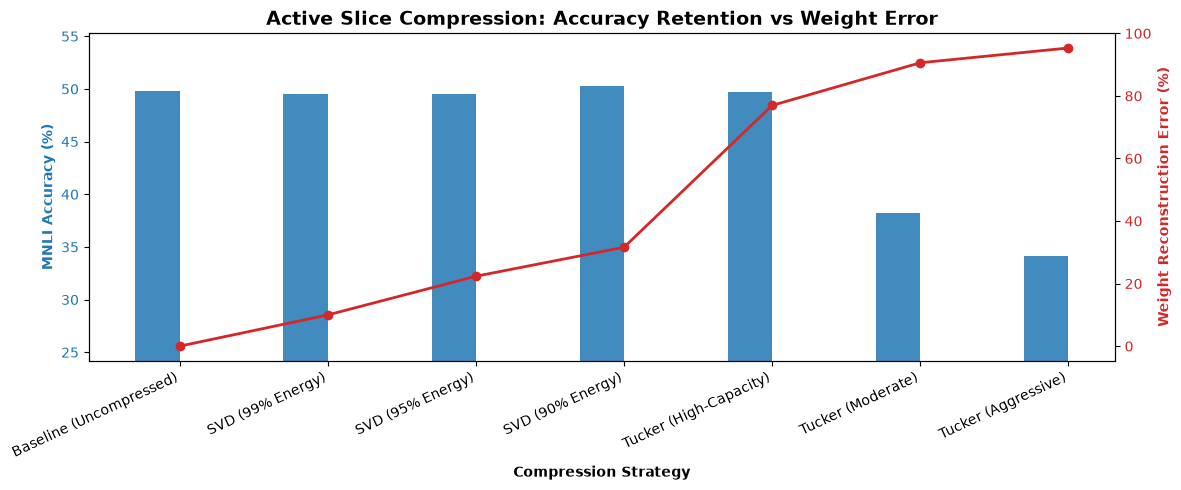

time: 0.19s
cummulative_time: 1734.97s


In [ ]:
# =====================================================================
# STEP 10: Comparative Analysis, Global Time Log & Results Export
# =====================================================================
all_entries = [
    {
        "Variant": "Baseline (Uncompressed)",
        "Parameters": W_active.numel(),
        "Ratio": "1.00x",
        "Reduction (%)": "0.0%",
        "Recon Err (%)": "0.0%",
        "Accuracy (%)": f"{baseline_accuracy * 100:.2f}%",
        "Delta vs Base": "+0.00%",
    }
]

for res in svd_results + tucker_results:
    all_entries.append({
        "Variant": res["strategy"],
        "Parameters": int(res["parameters"]),
        "Ratio": f"{res['compression_ratio']:.2f}x",
        "Reduction (%)": f"{res['eliminated_pct']:.1f}%",
        "Recon Err (%)": f"{res['recon_error_pct']:.2f}%",
        "Accuracy (%)": f"{res['accuracy'] * 100:.2f}%",
        "Delta vs Base": f"{res['delta'] * 100:+.2f}%",
    })

print("=" * 95)
print(f"{'Variant':<28} | {'Params':<9} | {'Ratio':<6} | {'Cut %':<6} | {'Err %':<7} | {'Accuracy':<9} | {'Delta':<7}")
print("=" * 95)
for row in all_entries:
    print(f"{row['Variant']:<28} | {row['Parameters']:<9} | {row['Ratio']:<6} | {row['Reduction (%)']:<6} | {row['Recon Err (%)']:<7} | {row['Accuracy (%)']:<9} | {row['Delta vs Base']:<7}")
print("=" * 95)

# Global Notebook Timing
total_notebook_runtime = time.time() - GLOBAL_NOTEBOOK_START_TIME
print(f"cummulative_time: {total_notebook_runtime:.2f}s")

# Save experiment run to artifacts
artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
output_path = artifact_dir / "04_active_acts_results.json"

export_data = {
    "model_id": model_id,
    "eval_samples": len(eval_data),
    "active_neurons": NUM_ACTIVE,
    "baseline_accuracy": baseline_accuracy,
    "results": all_entries,
    "timing_summary": {
        "cummulative_time_sec": round(total_notebook_runtime, 3),
        "cell_timings": NOTEBOOK_TIMINGS,
    },
}

save_json_metrics(export_data, output_path)
print(f"\nBenchmark results & timing data saved to: {output_path}")

# Plot Accuracy vs Parameters
variants = [row['Variant'] for row in all_entries]
accs = [float(row['Accuracy (%)'].replace('%', '')) for row in all_entries]
errors = [float(row['Recon Err (%)'].replace('%', '')) for row in all_entries]

fig, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(variants))

color = 'tab:blue'
ax1.set_xlabel('Compression Strategy', fontweight='bold')
ax1.set_ylabel('MNLI Accuracy (%)', color=color, fontweight='bold')
bars = ax1.bar(x - 0.15, accs, width=0.3, color=color, label='Accuracy (%)', alpha=0.85)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(variants, rotation=25, ha='right')
ax1.set_ylim(bottom=max(0, min(accs) - 10), top=max(accs) + 5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Weight Reconstruction Error (%)', color=color, fontweight='bold')
lines = ax2.plot(x, errors, color=color, marker='o', linewidth=2, label='Recon Error (%)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Active Slice Compression: Accuracy Retention vs Weight Error", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()